In [120]:
# Imports (DO NOT MODIFY)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, accuracy_score

In [121]:
# ============================================================
# Data Loading and Preprocessing (DO NOT MODIFY)
# ============================================================
iris = load_iris()
X = iris.data.astype(np.float64)
y = iris.target.astype(int)

sss1 = StratifiedShuffleSplit(n_splits=1, train_size=100, test_size=50, random_state=42)
train_idx, temp_idx = next(sss1.split(X, y))
X_train, y_train = X[train_idx], y[train_idx]
X_temp,  y_temp  = X[temp_idx],  y[temp_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, train_size=25, test_size=25, random_state=42)
val_idx, test_idx = next(sss2.split(X_temp, y_temp))
X_val, y_val   = X_temp[val_idx],  y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

mu = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True) + 1e-12
X_train = (X_train - mu) / sigma
X_val   = (X_val   - mu) / sigma
X_test  = (X_test  - mu) / sigma

def one_hot(labels, num_classes=3):
    out = np.zeros((labels.shape[0], num_classes))
    out[np.arange(labels.shape[0]), labels] = 1.0
    return out
Y_train = one_hot(y_train)
Y_val   = one_hot(y_val)
Y_test  = one_hot(y_test)

In [122]:
# ============================================================
# Activation Functions and Loss (TODO)
# ============================================================

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv_from_output(a):
    return a * (1 - a)
def cost_sse_half(y_hat, y_true):
    return 0.5 * np.sum((y_hat - y_true) ** 2)

In [123]:
# ============================================================
# Three-Layer Neural Network (TODO)
# ============================================================
class ThreeLayerNN:
    def __init__(self, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.uniform(-1, 1, size=(10, 4))
        self.b1 = rng.uniform(-1, 1, size=(10,))
        self.W2 = rng.uniform(-1, 1, size=(8,10))
        self.b2 = rng.uniform(-1, 1, size=(8,))
        self.W3 = rng.uniform(-1, 1, size=(3, 8))
        self.b3 = rng.uniform(-1, 1, size=(3,))

        

    def forward(self, x):
        self.x = x
        self.z1 = self.W1 @ self.x + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.W2 @ self.a1 + self.b2
        self.a2 = relu(self.z2)
        self.z3 = self.W3 @ self.a2 + self.b3
        self.a3 = sigmoid(self.z3)
        return self.a3

    def backward(self, cache, y_true):
        self.y_true = y_true
        self.dz3 = (self.a3 - self.y_true) * sigmoid_deriv_from_output(self.a3)
        self.dW3 = self.dz3[:, None] @ self.a2[None, :]
        self.db3 = self.dz3
        self.da2 = self.W3.T @ self.dz3
        self.dz2 = self.da2 * relu_deriv(self.z2)
        self.dW2 = self.dz2[:, None] @ self.a1[None, :]
        self.db2 = self.dz2
        self.da1 = self.W2.T @ self.dz2
        self.dz1 = self.da1 * relu_deriv(self.z1)
        self.dW1 = self.dz1[:, None] @ self.x[None, :]
        self.db1 = self.dz1 

    def sgd_step(self, grads, eta):
        self.W3 -= eta * self.dW3
        self.b3 -= eta * self.db3
        self.W2 -= eta * self.dW2
        self.b2 -= eta * self.db2
        self.W1 -= eta * self.dW1
        self.b1 -= eta * self.db1
        
    def predict(self, X):
        y_hats = []
        for x in X:
            y_hat = self.forward(x)
            y_hats.append(y_hat)
        return np.array(y_hats)

In [124]:
# ============================================================
# Learning Rate Schedulers (TODO)
# ============================================================
# Fixed learning rates
FIXED_LRS = [0.05, 0.25, 0.5]

# Power schedule hyperparameters (given)
POWER_ETA0 = 0.10
POWER_C    = 0.01
POWER_S    = 5000

# Exponential schedule hyperparameters (given)
EXP_ETA0   = 0.10
EXP_S      = 5000

# TODO: implement fixed, power, and exponential schedulers
def lr_fixed(lr):
    return lambda iter: lr

def lr_power(n):
    return lambda n: POWER_ETA0 / (1 + (n / POWER_S)**POWER_C)

def lr_exp(n):
    return lambda n: EXP_ETA0 * (0.1 ** (n / EXP_S))

In [125]:
# ============================================================
# Training Loop (TODO)
# ============================================================
def train_sgd(
    name,
    lr_fn_iter,
    seed=0,
    epochs=160,
    val_stop_thresh=1e-3
):
    model_0 = ThreeLayerNN(seed = seed) 
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None
    best_params = (
                model_0.W1.copy(), model_0.b1.copy(),
                model_0.W2.copy(), model_0.b2.copy(),
                model_0.W3.copy(), model_0.b3.copy()
            )
    for epoch in range(epochs):
        for i in range(X_train.shape[0]):
            x = X_train[i]
            y_true = Y_train[i]
            y_train = model_0.forward(x)
            model_0.backward(None, y_true)
            lr = lr_fn_iter(epoch * X_train.shape[0] + i)
            model_0.sgd_step(None, lr)
        train_loss = cost_sse_half(model_0.predict(X_train), Y_train)
        val_loss = cost_sse_half(model_0.predict(X_val), Y_val)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = (
                model_0.W1.copy(), model_0.b1.copy(),
                model_0.W2.copy(), model_0.b2.copy(),
                model_0.W3.copy(), model_0.b3.copy()
            )
        if epoch % 10 ==0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    # Create a new model with the best parameters
    best_model = ThreeLayerNN(seed=seed)
    best_model.W1, best_model.b1, best_model.W2, best_model.b2, best_model.W3, best_model.b3 = best_params
    if epoch > 0 and abs(val_losses[-2] - val_losses[-1]) < val_stop_thresh:
        print(f"Suggested early stopping at epoch {epoch} for {name}, but continuing to train for full {epochs} epochs.")
    return best_model, train_losses, val_losses

Answer to question 1 (Epoch count): I trained my model for a total of 160 epochs. My reasoning for this, was after testing multiple different epoch counts, the exponential learning rate gave me the best validation accuracy overall. The exponential learning rate converged at about 160 epochs, and therefore I did not need anymore iterations to determine my best model. 

Epoch 1/160 - Train Loss: 12.6059, Val Loss: 3.3957
Epoch 11/160 - Train Loss: 1.9087, Val Loss: 1.1117
Epoch 21/160 - Train Loss: 1.2388, Val Loss: 1.2718
Epoch 31/160 - Train Loss: 0.9521, Val Loss: 1.3741
Epoch 41/160 - Train Loss: 0.7806, Val Loss: 1.3869
Epoch 51/160 - Train Loss: 0.6268, Val Loss: 1.3980
Epoch 61/160 - Train Loss: 0.5033, Val Loss: 1.4102
Epoch 71/160 - Train Loss: 0.4114, Val Loss: 1.4409
Epoch 81/160 - Train Loss: 0.3116, Val Loss: 1.4417
Epoch 91/160 - Train Loss: 0.2280, Val Loss: 1.4698
Epoch 101/160 - Train Loss: 0.1724, Val Loss: 1.4913
Epoch 111/160 - Train Loss: 0.1323, Val Loss: 1.4957
Epoch 121/160 - Train Loss: 0.1128, Val Loss: 1.5201
Epoch 131/160 - Train Loss: 0.0955, Val Loss: 1.5370
Epoch 141/160 - Train Loss: 0.0779, Val Loss: 1.5423
Epoch 151/160 - Train Loss: 0.0691, Val Loss: 1.5543
fixed learning rate losses for lr 0.05: train=0.0611, val=1.5634
Epoch 1/160 - Train Loss: 10.2484, Val Loss: 3.6085
Epoch 11/160 - Train Loss: 3.9170, Val Loss: 

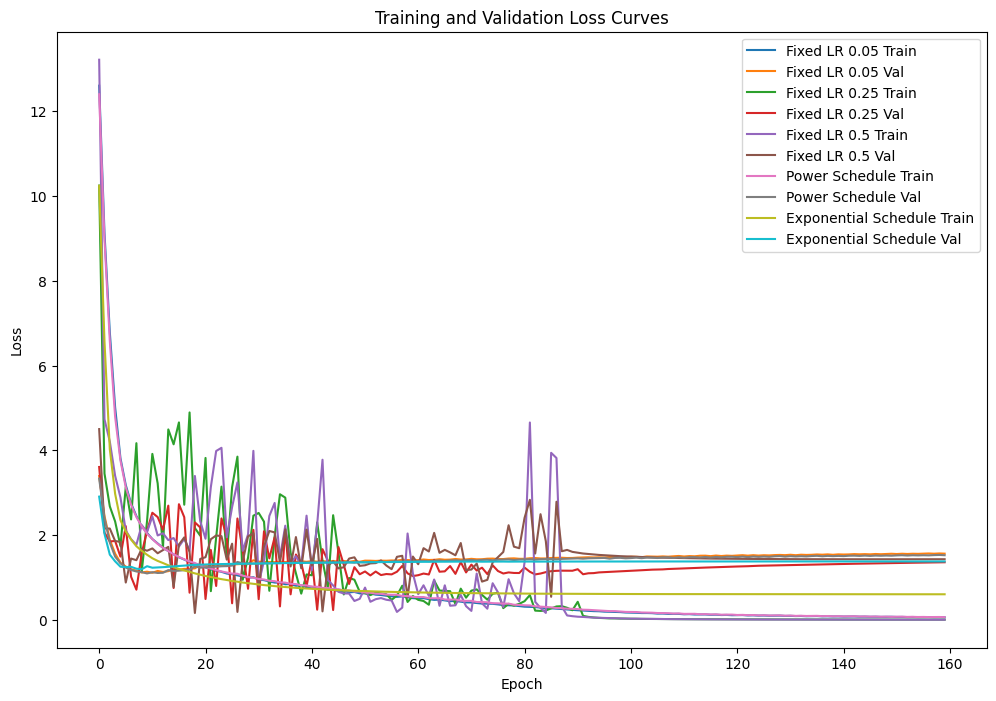

Best model validation loss: 1.3599
Accuracy for power scheduling: 0.8800
Accuracy for exponential scheduling: 0.8800
Accuracy for fixed learning rates: [0.88, 0.96, 0.96]
Best model test accuracy: 0.9600


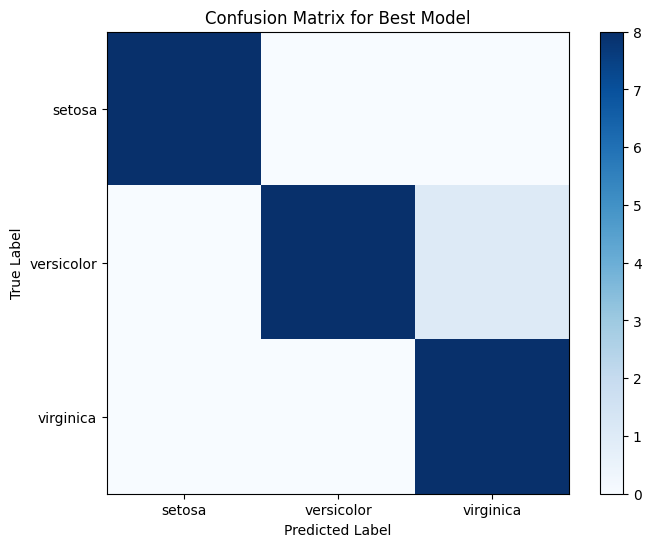

In [126]:
# ============================================================
# Experiments and Plots (TODO)
# ============================================================
# TODO:
# 1. Train models with fixed learning rates
# 2. Train models with power and exponential scheduling
# 3. Plot training and validation loss curves for each
# 4. Select best model based on validation performance
# 5. Evaluate on test set and plot confusion matrix
# Train with fixed learning rates
models_fixed = []
for lr in FIXED_LRS:
    model, train_losses, val_losses = train_sgd(f"Fixed LR {lr}", lr_fixed(lr))
    models_fixed.append((model, train_losses, val_losses))
    print(f"fixed learning rate losses for lr {lr}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
# Train with power scheduling
model_power, train_losses_power, val_losses_power = train_sgd("Power Schedule", lr_power(POWER_C))
print(f"power schedule losses: train={train_losses_power[-1]:.4f}, val={val_losses_power[-1]:.4f}")
# Train with exponential scheduling
model_exp, train_losses_exp, val_losses_exp = train_sgd("Exponential Schedule", lr_exp(EXP_S))
print(f"exponential schedule losses: train={train_losses_exp[-1]:.4f}, val={val_losses_exp[-1]:.4f}")
# Plot training and validation loss curves
plt.figure(figsize=(12, 8))
for i, (model, train_losses, val_losses) in enumerate(models_fixed):
    plt.plot(train_losses, label=f"Fixed LR {FIXED_LRS[i]} Train")
    plt.plot(val_losses, label=f"Fixed LR {FIXED_LRS[i]} Val")
plt.plot(train_losses_power, label="Power Schedule Train")
plt.plot(val_losses_power, label="Power Schedule Val")
plt.plot(train_losses_exp, label="Exponential Schedule Train")
plt.plot(val_losses_exp, label="Exponential Schedule Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.show()
# Select best model based on validation performance
best_model = None
best_val_loss = float('inf')
for model, train_losses, val_losses in models_fixed:
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_model = model
if val_losses_power[-1] < best_val_loss:
    best_val_loss = val_losses_power[-1]
    best_model = model_power
if val_losses_exp[-1] < best_val_loss:
    best_val_loss = val_losses_exp[-1]
    best_model = model_exp
# Evaluate on test set and plot confusion matrix

print(f"Best model validation loss: {best_val_loss:.4f}")
print(f"Accuracy for power scheduling: {accuracy_score(y_test, np.argmax(model_power.predict(X_test), axis=1)):.4f}")
print(f"Accuracy for exponential scheduling: {accuracy_score(y_test, np.argmax(model_exp.predict(X_test), axis=1)):.4f}")
print(f"Accuracy for fixed learning rates: {[accuracy_score(y_test, np.argmax(model.predict(X_test), axis=1)) for model, _, _ in models_fixed]}")
print(f"Best model test accuracy: {accuracy_score(y_test, np.argmax(best_model.predict(X_test), axis=1)):.4f}")
y_test_pred = np.argmax(best_model.predict(X_test), axis=1)
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix for Best Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.xticks(np.arange(3), iris.target_names)
plt.yticks(np.arange(3), iris.target_names)
plt.show()      

Answer to question 1(Fixed learning rate observation): It seems to me that the smallest learning rate (.05), not only gave the most significant error, but also took the longest to converge. The next step (.25) was better, but overall, the last fixed learning rate (.5) converged the fastest and ended up giving the smallest training error overall. I did observe, however, that the difference between error of the .05 and .25 learning rates was significantly higher than the difference between .25 and .5 step size. However, the .5 step size was more eratic with the changes in error compared to the others.

Answer to question 1(Fixed VS. Exponential VS. Power): Exponential scheduling converged the fastest overall, and had the best validation loss. Power scheduling and exponential scheduling both started off with great validation losses, then slowly started increasing as the number of epochs increased. This suggests mild overfitting as training continues, since training performance improves while validation performance degrades. They also both had less eratic changes than the fixed learning rates when it came to training error; However, the fixed learning rates ended up having more favorable losses for training data. In conclusion, it seems like power and exponential scheduling converge faster, but fixed scheduling gives better training loss, with worse validation loss.

Accuracy scores: It seems as though the fixed learning rates of .25 and .5 gave the best accuracy overall, even though they did not have the best validation losses. These does seem to be a discrepancy between the validation and training data. I believe this is due to the fact that the validation set is not used to update the weights, it is only used to "validate" our weights as they are updated. This considered, our validation losses will be higher than training losses because validation data is our new data. The accuracy of each schedule are labeled above, as well as the graph and confusion matrix. 